In [8]:
import numpy as np
import pandas as pd

In [12]:
# Load the CSV file into a pandas DataFrame, skipping problematic lines
df = pd.read_csv(r'C:\Users\beego\Desktop\Visualcode_Courses\STEMACADEMY\streamlit_app\data\HousingPrices_selected.csv', on_bad_lines='skip', delimiter=',')
# Display the first few rows of the DataFrame
df.head()

,Postnummer,Husnummer,kvadratmeter,Grundareal,Byggeår,afstand_skole,afstand_supermarked,Salgspris
0,4953.0,9.0,97,949.0,1942.0,5425.42,5551.78,1050000
1,2300.0,12.0,86,0.0,2006.0,1045.23,132.97,1352500
2,2300.0,12.0,86,0.0,2006.0,1045.23,132.97,3500000
3,2300.0,16.0,95,0.0,2007.0,1017.53,153.93,3463432
4,2300.0,18.0,73,0.0,2007.0,1004.49,166.23,2700000


In [13]:
# Load the diabetes dataset from scikit-learn
from sklearn.datasets import load_diabetes
import pandas as pd

# Load the dataset
diabetes = load_diabetes()

# Convert to pandas DataFrame
diabetes_df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)

# Display the first few rows of the DataFrame
diabetes_df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


Overlapping columns with NaNs: {'MI_OBJ_OIS_TAXATION_VALUE_PLOT', 'MI_OBJ_OIS_TAXATION_VALUE', 'MI_OBJ_OIS_SUM_OF_TAXATION_VALUES', 'SUPERMARKET_DISTANCE_1', 'MI_OBJ_OIS_MOTHER_ID', 'MI_OBJ_OIS_CONSTRUCTION_YEAR'}


In [14]:
# Check the size of the dataset
rows, columns = df.shape
print(f"The dataset contains {rows} rows and {columns} columns.")

The dataset contains 48255 rows and 8 columns.


In [26]:
# Identify categorical columns in the dataset
categorical_columns = df.select_dtypes(include=['object', 'category']).columns
print("Categorical columns in the dataset:")
print(categorical_columns.tolist())

Categorical columns in the dataset:
['MI_OBJ_OIS_RENTED_PLOT', 'MI_OBJ_OIS_DATE_OF_TAXATION_VALUE', 'MI_OBJ_OIS_PROPERTY_ADDRESS', 'MI_OBJ_OIS_HOUSE_LETTER', 'MI_OBJ_OIS_FLOOR_NUMBER', 'MI_OBJ_OIS_MAX_FLOOR_NUMBER_BUILDING', 'MI_OBJ_OIS_LAND_ZONE', 'MI_OBJ_OIS_CONSTRUCTION_MATERIAL', 'MI_OBJ_OIS_ROOF_MATERIAL', 'OMREGNINGS_DATO']


In [28]:
# Display the first five rows of each categorical column
for column in categorical_columns:
    print(f"First five rows of column: {column}")
    print(df[column].head(10))
    print("\n")

First five rows of column: MI_OBJ_OIS_RENTED_PLOT
0    N
1    N
2    N
3    N
4    N
5    N
6    N
7    N
8    N
9    N
Name: MI_OBJ_OIS_RENTED_PLOT, dtype: object


First five rows of column: MI_OBJ_OIS_DATE_OF_TAXATION_VALUE
0    2013-10-01
1    2014-10-01
2    2014-10-01
3    2014-10-01
4    2014-10-01
5    2013-10-01
6    2013-10-01
7    2013-10-01
8    2014-10-01
9    2014-10-01
Name: MI_OBJ_OIS_DATE_OF_TAXATION_VALUE, dtype: object


First five rows of column: MI_OBJ_OIS_PROPERTY_ADDRESS
0             Rudbjergvej 9 (4953)
1    Jens Otto Krags Gade 12 03 tv
2    Jens Otto Krags Gade 12 04 tv
3    Jens Otto Krags Gade 16 01 tv
4    Jens Otto Krags Gade 18 st tv
5    Jens Otto Krags Gade 20 01 th
6            Rebslagervej 21 st th
7            Rebslagervej 21 03 th
8           Rentemestervej 5 02 mf
9         Rentemestervej 7 B 04 tv
Name: MI_OBJ_OIS_PROPERTY_ADDRESS, dtype: object


First five rows of column: MI_OBJ_OIS_HOUSE_LETTER
0     
1     
2     
3     
4     
5     
6     


In [16]:
# DecisionTreeRegressor on 'KOEBESUM_BELOEB'
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Ensure the target column exists
if 'Salgspris' in df.columns:
    # Separate features and target
    X = df.drop(columns=['Salgspris'])
    y = df['Salgspris']

    # Handle missing values (drop rows with NaN for simplicity)
    #X = X.dropna()
    y = y[X.index]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the model
    regressor = DecisionTreeRegressor(random_state=42)
    regressor.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = regressor.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")
else:
    print("The target column 'KOEBESUM_BELOEB' does not exist in the dataset.")

Mean Squared Error: 41721378986866.94


In [21]:
### XGBoost Regressor on Housing Prices
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Ensure the target column exists
if 'KOEBESUM_BELOEB' in df.columns:
    # Use only 20% of the data
    df_sampled = df.sample(frac=1.0, random_state=42)

    # Separate features and target
    X = df_sampled.drop(columns=['KOEBESUM_BELOEB'])
    y = df_sampled['KOEBESUM_BELOEB']

    # Drop categorical columns completely
    X = X.select_dtypes(exclude=['object'])
    #X = pd.get_dummies(X, drop_first=True)

    # Handle missing values (fill NaN with 0 for simplicity)
    #X = X.fillna(0)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the XGBoost Regressor
    xgb_regressor = XGBRegressor(random_state=42)
    xgb_regressor.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = xgb_regressor.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error (XGBoost): {mse}")
else:
    print("The target column 'KOEBESUM_BELOEB' does not exist in the dataset.")

Mean Squared Error (XGBoost): 27623010861056.0


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002543 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1683
[LightGBM] [Info] Number of data points in the train set: 38604, number of used features: 7
[LightGBM] [Info] Start training from score 2221275.849731
Mean Squared Error (LightGBM): 17901751314242.72
Mean Squared Error (LightGBM): 17901751314242.72


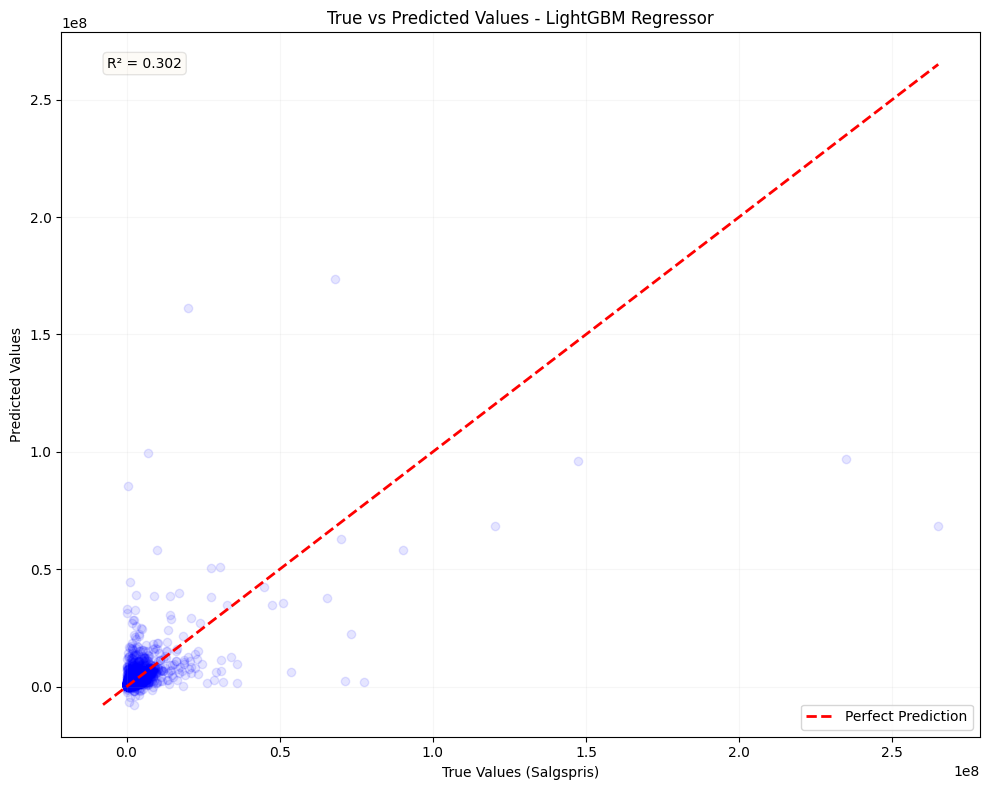

In [ ]:
### LGBM Regressor for Housing Prices
from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

# Ensure the target column exists
if 'Salgspris' in df.columns:
    # Use only 20% of the data
    df_sampled = df.sample(frac=1.0, random_state=42)

    # Separate features and target
    X = df_sampled.drop(columns=['Salgspris'])
    y = df_sampled['Salgspris']

    # Drop categorical columns completely
    #X = X.select_dtypes(exclude=['object'])
    X = pd.get_dummies(X, drop_first=True)

    # Handle missing values (fill NaN with 0 for simplicity)
    X = X.fillna(0)

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Train the LightGBM Regressor with MAE objective (L1 loss)
    lgbm_regressor = LGBMRegressor(objective='regression_l1', random_state=42)
    lgbm_regressor.fit(X_train, y_train)

    # Predict and evaluate
    y_pred = lgbm_regressor.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Absolute Error (LightGBM trained on MAE): {mae}")
    print(f"Mean Squared Error (for comparison): {mse}")
    
    # True vs Predicted plot
    plt.figure(figsize=(10, 8))
    plt.scatter(y_test, y_pred, alpha=0.1, color='blue')
    
    # Perfect prediction line
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
    
    plt.xlabel('True Values (Salgspris)')
    plt.ylabel('Predicted Values')
    plt.title('True vs Predicted Values - LightGBM Regressor (MAE Objective)')
    plt.legend()
    plt.grid(True, alpha=0.1)
    
    # Add R² score
    from sklearn.metrics import r2_score
    r2 = r2_score(y_test, y_pred)
    plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.1))
    
    plt.tight_layout()
    plt.show()
    
else:
    print("The target column 'Salgspris' does not exist in the dataset.")

Feature Ranking:
1. MI_OBJ_OIS_SUM_OF_TAXATION_VALUES: 288
2. MI_OBJ_OIS_SIZE_OF_BUSINESS_AREA: 199
3. MI_OBJ_OIS_MOTHER_ID: 187
4. MI_OBJ_OIS_TAXATION_VALUE: 170
5. MI_OBJ_OIS_CONSTRUCTION_YEAR: 153
6. MI_OBJ_OIS_SIZE_OF_BUSINESS_AREA_BUILDING: 145
7. MI_OBJ_OIS_SIZE_OF_BASEMENT: 136
8. MI_OBJ_OIS_SIZE_OF_HOUSE: 102
9. C20_6MONTH%: 99
10. MI_OBJ_OIS_TAXATION_VALUE_PLOT: 91
11. MI_OBJ_OIS_OWNERSHIP_CODE_PROPERTY: 86
12. MI_OBJ_OIS_NUMBER_OF_FLOORS: 86
13. SUPERMARKET_DISTANCE_1: 85
14. MI_OBJ_OIS_SIZE_OF_ATTIC: 76
15. MI_OBJ_OIS_SIZE_OF_HOUSE_EXCL_UTILIZED_ATTIC: 75
16. SUPERMARKET_DISTANCE_2: 70
17. SCHOOL_DISTANCE_3: 66
18. MI_OBJ_OIS_PROPERTY_ID: 65
19. SCHOOL_DISTANCE_1: 65
20. SUPERMARKET_DISTANCE_3: 65
21. MI_OBJ_OIS_N_COORDINATE: 64
22. SCHOOL_DISTANCE_2: 59
23. C20_3MONTH%: 59
24. MI_OBJ_OIS_PROPERTY_NUMBER: 58
25. MI_OBJ_OIS_PROPERTY_USE_CODE: 45
26. MI_OBJ_OIS_POSTAL_CODE: 45
27. MI_OBJ_OIS_SIZE_OF_PLOT: 42
28. C20_12MONTH%: 42
29. C20_1MONTH%: 39
30. MI_OBJ_OIS_SIZE_OF_USED_

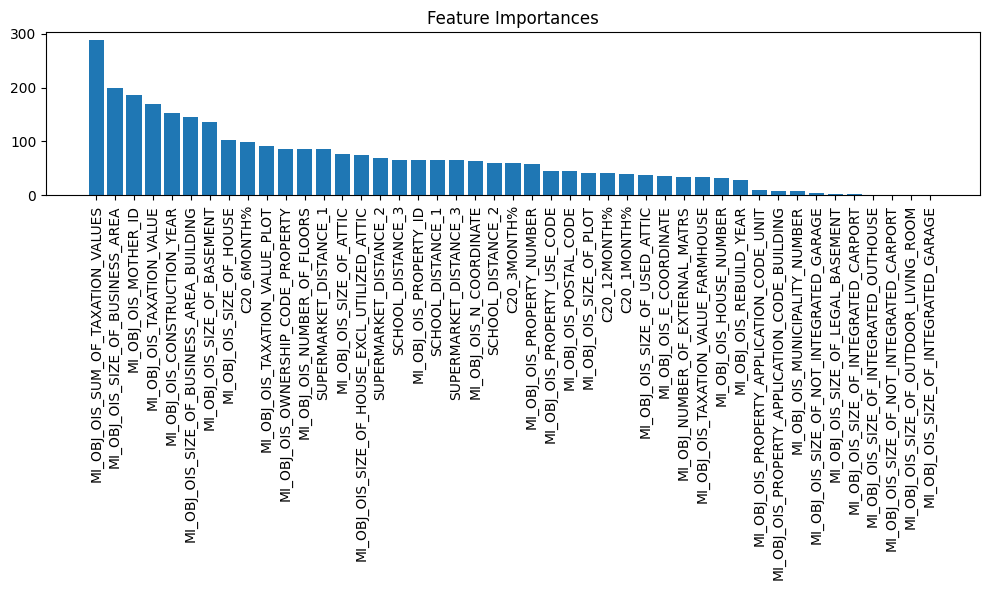

In [23]:
### Feature Importance Ranking
import matplotlib.pyplot as plt
import numpy as np

# Ensure the model and data exist
if 'lgbm_regressor' in locals() and 'X_train' in locals():
    feature_importances = lgbm_regressor.feature_importances_
    feature_names = X_train.columns

    # Sort features by importance
    indices = np.argsort(feature_importances)[::-1]
    sorted_features = feature_names[indices]
    sorted_importances = feature_importances[indices]

    # Display feature importance
    print("Feature Ranking:")
    for i, (feature, importance) in enumerate(zip(sorted_features, sorted_importances)):
        print(f"{i + 1}. {feature}: {importance}")

    # Plot feature importance
    plt.figure(figsize=(10, 6))
    plt.title("Feature Importances")
    plt.bar(range(len(feature_importances)), sorted_importances, align="center")
    plt.xticks(range(len(feature_importances)), sorted_features, rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("Model or training data not found. Please ensure the model is trained.")

In [24]:
### Save CSV with Top 10 Features and Target Column

# Ensure the model and data exist
if 'lgbm_regressor' in locals() and 'X_train' in locals():
    feature_importances = lgbm_regressor.feature_importances_
    feature_names = X_train.columns

    # Sort features by importance
    indices = np.argsort(feature_importances)[::-1]
    top_10_features = feature_names[indices][:10]

    # Filter the original dataset to include only the top 10 features and the target column
    top_10_df = df[top_10_features]
    top_10_df['Target'] = df['KOEBESUM_BELOEB']

    # Save to a new CSV file
    #top_10_df.to_csv('HP_TOP_10_LGBM_Cleaned.csv', index=False)
    print("CSV file with top 10 features and target column saved as 'HP_TOP_10_LGBM.csv'.")
else:
    print("Model or training data not found. Please ensure the model is trained.")

C:\Users\beego\AppData\Local\Temp\ipykernel_1296\220481333.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top_10_df['Target'] = df['KOEBESUM_BELOEB']


CSV file with top 10 features and target column saved as 'HP_TOP_10_LGBM.csv'.


For now I drop columns with categorical data as these do not want to cooperate.

For Next time:
- Start by make sure you can perform regression on each column, i.e., remove nan entries.
- You could alternatively make the nan go to 0s for example.

        This doesnt make any difference, so I decided against it.
- Perhaps make sure that columns that you keep dont have 0 entries.

Later:
- Connect to github
- Implement XGBoost
- Classification
- look at choosing features/variables again

One hot encoding på alle 'categories' indenfor categorical data virker ikke out of the box. *Prøver at tilføje 38k kolonner* *13GB array*

- Tanker: Hvor meget skal datasættet renses. Det lige nu er renset så det virker men en del information er fjernet. Det skal bare være en demo så performance er vel ikke et strengt kriterie. Måske skal man endda vælge kolonner der er 'håndgribelige'.
- Visualisering af MSE?
- Jeg har undladt at indføre NN da det er det Maja er i gang med. 

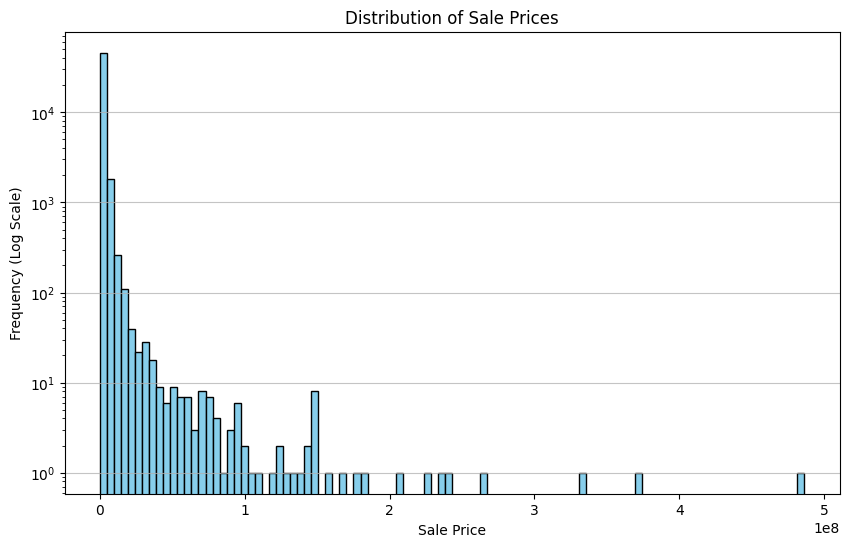

In [20]:
#Plot distribution of target varaible from this file "C:\Users\beego\Desktop\Visualcode_Courses\STEMACADEMY\streamlit_app\data\HousingPrices_selected.csv"
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv("C:\\Users\\beego\\Desktop\\Visualcode_Courses\\STEMACADEMY\\streamlit_app\\data\\HousingPrices_selected.csv")

# Plot the distribution of the target variable with logarithmic y-axis
plt.figure(figsize=(10, 6))
plt.hist(data['Salgspris'], bins=100, color='skyblue', edgecolor='black')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency (Log Scale)')
plt.yscale('log')  # Set y-axis to logarithmic scale

plt.grid(axis='y', alpha=0.75)
plt.show()